In [1]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

### *Bit-Flip Code*

In [35]:
q_reg = QuantumRegister(3)
ancilla_reg = AncillaRegister(2)
c_reg = ClassicalRegister(2)
qc = QuantumCircuit(q_reg,ancilla_reg,c_reg)

qc.cx(q_reg[0],q_reg[1])
qc.cx(q_reg[0],q_reg[2])
qc.barrier()

# qc.x(q_reg[2])  -> we can add error on any qubits by applying x gate(a full bit flip error)
qc.cx(q_reg[0],ancilla_reg[0])
qc.cx(q_reg[1],ancilla_reg[0])
qc.cx(q_reg[1],ancilla_reg[1])
qc.cx(q_reg[2],ancilla_reg[1])

qc.measure(ancilla_reg,c_reg)

with qc.if_test((c_reg, 1)):
    qc.x(q_reg[0])
with qc.if_test((c_reg, 2)):
    qc.x(q_reg[2])
with qc.if_test((c_reg, 3)):
    qc.x(q_reg[1])

sim = AerSimulator()
t_qc = transpile(qc,sim)
counts = sim.run(t_qc,shots = 1024).result().get_counts()


print(counts)


{'00': 1024}


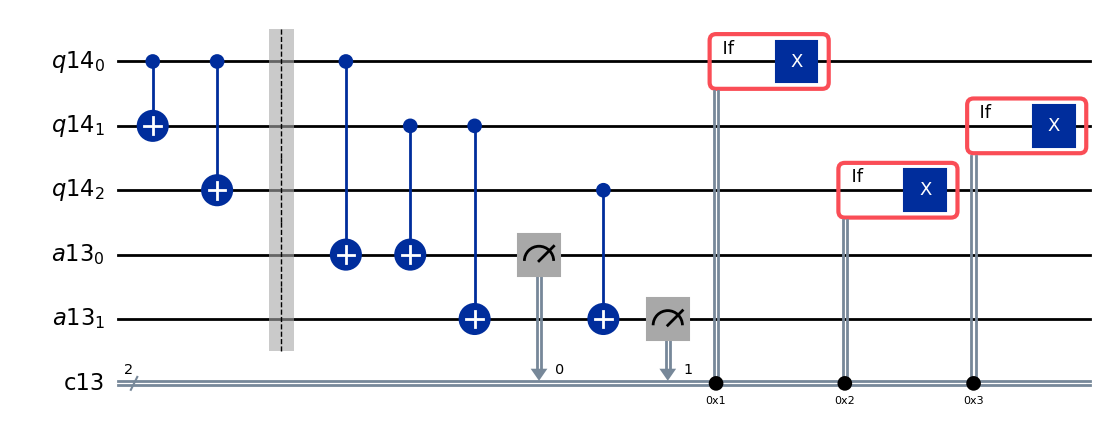

In [36]:
qc.draw("mpl")

### *Phase-Flip Code*

In [37]:
q_reg = QuantumRegister(3)
ancilla_reg = AncillaRegister(2)
c_reg = ClassicalRegister(2)
qc = QuantumCircuit(q_reg,ancilla_reg,c_reg)

qc.cx(q_reg[0],q_reg[1])
qc.cx(q_reg[0],q_reg[2])
qc.barrier()

qc.h(q_reg)
qc.z(q_reg[0]) # -> we can add error on any qubits by applying z gate(a full phase flip(180 rotation) error)
qc.barrier()

qc.h([q_reg[0],q_reg[1],q_reg[2]])
qc.cx(q_reg[0],ancilla_reg[0])
qc.cx(q_reg[1],ancilla_reg[0])
qc.cx(q_reg[1],ancilla_reg[1])
qc.cx(q_reg[2],ancilla_reg[1])
qc.h([q_reg[0],q_reg[1],q_reg[2]])


qc.measure(ancilla_reg,c_reg)

with qc.if_test((c_reg, 1)):
    qc.z(q_reg[0])
with qc.if_test((c_reg, 2)):
    qc.z(q_reg[2])
with qc.if_test((c_reg, 3)):
    qc.z(q_reg[1])

sim = AerSimulator()
t_qc = transpile(qc,sim)
counts = sim.run(t_qc,shots = 1024).result().get_counts()


print(counts)


{'01': 1024}


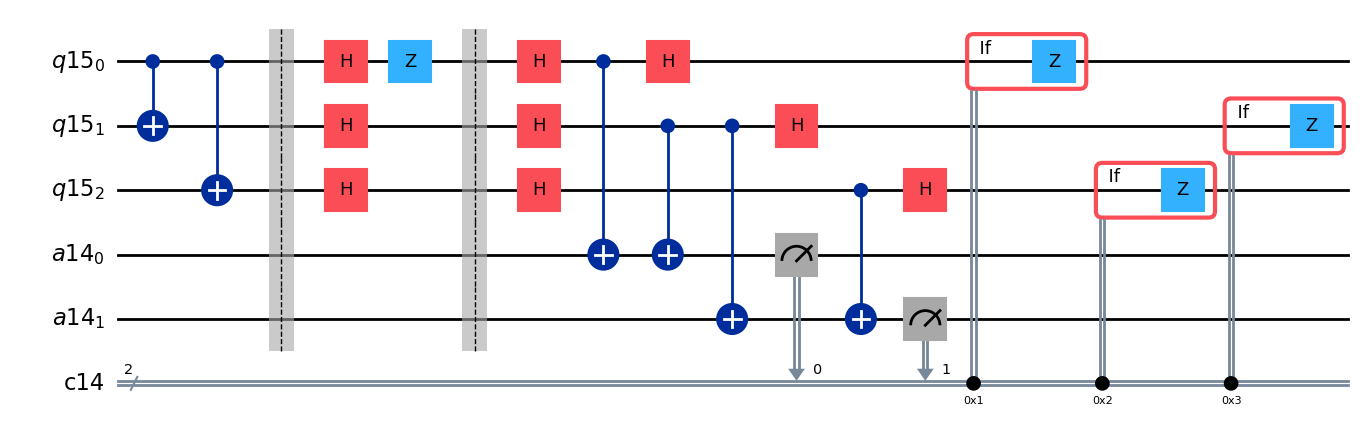

In [38]:
qc.draw('mpl')

## **Implementation of Shor's Code**